In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ola.csv')
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,#NAME?,NaN
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,No,NaN,158,Cash,13,4.1,4.0,#NAME?,NaN
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,No,NaN,386,UPI,40,4.2,4.8,#NAME?,NaN
3,2024-07-22 3:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,NaN,NaN,384,NaN,0,NaN,NaN,#NAME?,NaN
4,2024-07-02 9:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,No,NaN,822,Credit Card,45,4.0,3.0,#NAME?,NaN


In [3]:
df.shape

(103024, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  object 
 3   Booking_Status              103024 non-null  object 
 4   Customer_ID                 103024 non-null  object 
 5   Vehicle_Type                103024 non-null  object 
 6   Pickup_Location             103024 non-null  object 
 7   Drop_Location               103024 non-null  object 
 8   V_TAT                       63967 non-null   float64
 9   C_TAT                       63967 non-null   float64
 10  Canceled_Rides_by_Customer  10499 non-null   object 
 11  Canceled_Rides_by_Driver    18434 non-null   object 
 12  Incomplete_Rides            63967 non-null   object 
 13  Incomplete_Rid

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  object 
 3   Booking_Status              103024 non-null  object 
 4   Customer_ID                 103024 non-null  object 
 5   Vehicle_Type                103024 non-null  object 
 6   Pickup_Location             103024 non-null  object 
 7   Drop_Location               103024 non-null  object 
 8   V_TAT                       63967 non-null   float64
 9   C_TAT                       63967 non-null   float64
 10  Canceled_Rides_by_Customer  10499 non-null   object 
 11  Canceled_Rides_by_Driver    18434 non-null   object 
 12  Incomplete_Rides            63967 non-null   object 
 13  Incomplete_Rid

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time

In [7]:
df.isnull().sum()

Date                               0
Time                               0
Booking_ID                         0
Booking_Status                     0
Customer_ID                        0
Vehicle_Type                       0
Pickup_Location                    0
Drop_Location                      0
V_TAT                          39057
C_TAT                          39057
Canceled_Rides_by_Customer     92525
Canceled_Rides_by_Driver       84590
Incomplete_Rides               39057
Incomplete_Rides_Reason        99098
Booking_Value                      0
Payment_Method                 39057
Ride_Distance                      0
Driver_Ratings                 39057
Customer_Rating                39057
Vehicle Images                     0
Unnamed: 20                   103024
dtype: int64

In [8]:
print("Numerical Column Description:")
df.describe()

Numerical Column Description:


,Date,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating,Unnamed: 20
count,103024,63967.000000,63967.000000,103024.000000,103024.000000,63967.000000,63967.000000,0.0
mean,2024-07-16 11:31:38.879678720,170.876952,84.873372,548.751883,14.189927,3.997457,3.998313,NaN
min,2024-07-01 00:00:00,35.000000,25.000000,100.000000,0.000000,3.000000,3.000000,NaN
25%,2024-07-08 18:41:00,98.000000,55.000000,242.000000,0.000000,3.500000,3.500000,NaN
50%,2024-07-16 11:23:00,168.000000,85.000000,386.000000,8.000000,4.000000,4.000000,NaN
75%,2024-07-24 05:18:00,238.000000,115.000000,621.000000,26.000000,4.500000,4.500000,NaN
max,2024-07-31 23:58:00,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000,NaN
std,NaN,80.803640,36.005100,536.541221,15.776270,0.576834,0.578957,NaN


In [9]:
print("Categorical Column Description:")
df.describe(include=object)

Categorical Column Description:


,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Payment_Method,Vehicle Images
count,103024,103024,103024,103024,103024,103024,103024,10499,18434,63967,3926,63967,103024
unique,1440,103024,4,94544,7,50,50,5,4,2,3,4,1
top,00:53:00,CNR7153255142,Success,CID954071,Prime Sedan,Banashankari,Peenya,Driver is not moving towards pickup location,Personal & Car related issue,No,Customer Demand,Cash,#NAME?
freq,101,1,63967,5,14877,2201,2159,3175,6542,60041,1601,35022,103024


In [10]:
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,#NAME?,NaN
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,No,NaN,158,Cash,13,4.1,4.0,#NAME?,NaN
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,No,NaN,386,UPI,40,4.2,4.8,#NAME?,NaN
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,NaN,NaN,384,NaN,0,NaN,NaN,#NAME?,NaN
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,No,NaN,822,Credit Card,45,4.0,3.0,#NAME?,NaN


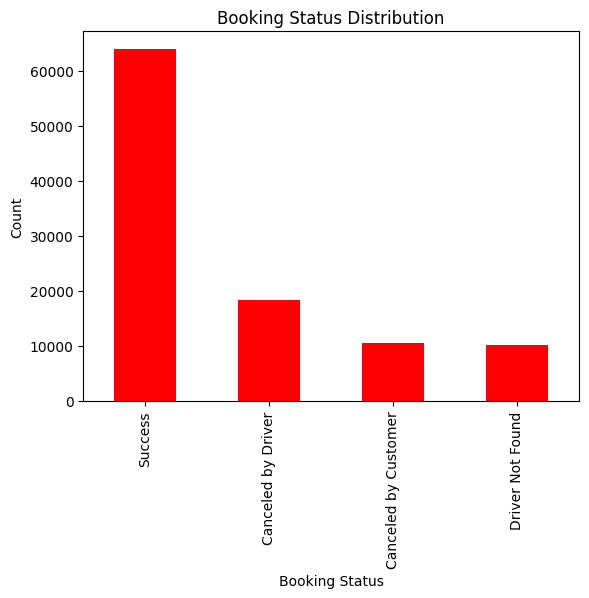

In [11]:
# Visualization of 'Booking_Status' column
plt.figure()
df['Booking_Status'].value_counts().plot(kind='bar', color='red')
plt.title('Booking Status Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.show()

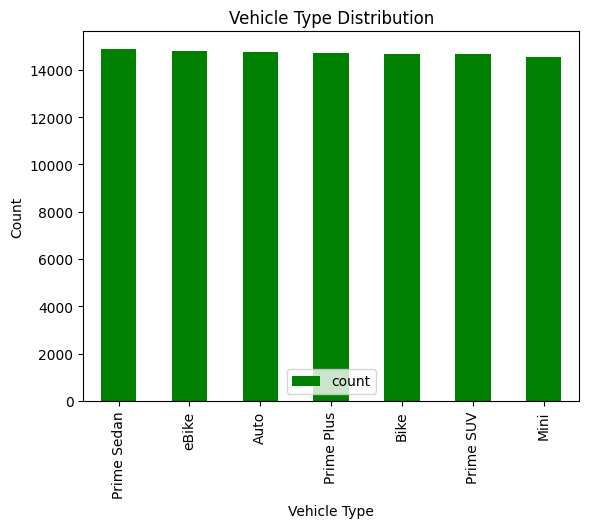

In [12]:
#Vehicle Type Distribution
plt.figure()
df['Vehicle_Type'].value_counts().plot(kind='bar', color='green', legend='reverse')
plt.title('Vehicle Type Distribution')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.legend()
plt.show()

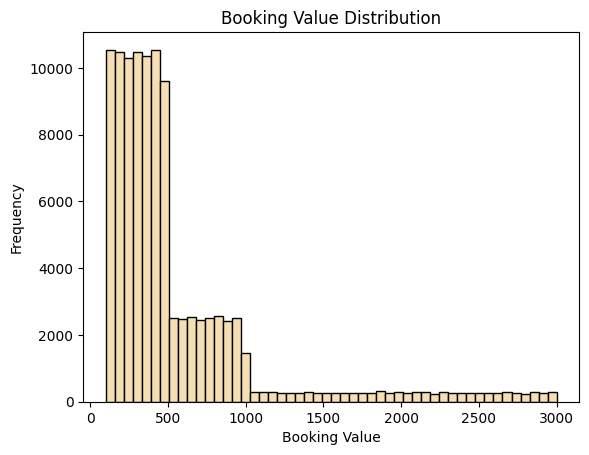

In [13]:
#Booking Value Distribution (Histogram)
plt.figure()
df['Booking_Value'].plot(kind='hist', bins=50, color='wheat', edgecolor='black')
plt.title('Booking Value Distribution')
plt.xlabel('Booking Value')
plt.ylabel('Frequency')
plt.show()

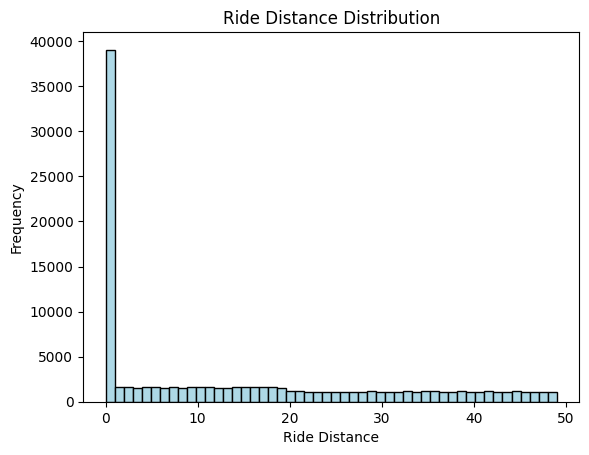

In [14]:
#Ride Distance Distribution
plt.figure()
df['Ride_Distance'].plot(kind='hist', bins=50, color='lightblue', edgecolor='black')
plt.title('Ride Distance Distribution')
plt.xlabel('Ride Distance')
plt.ylabel('Frequency')
plt.show()

<Figure size 640x480 with 0 Axes>

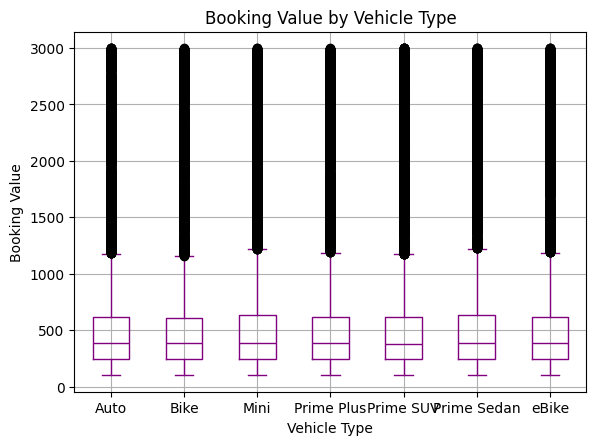

In [15]:
#Booking Value by Vehicle Type (Box Plot)
plt.figure()
df.boxplot(column='Booking_Value', by='Vehicle_Type', grid=True, color='purple')
plt.title('Booking Value by Vehicle Type')
plt.suptitle('')
plt.xlabel('Vehicle Type')
plt.ylabel('Booking Value')
plt.show()

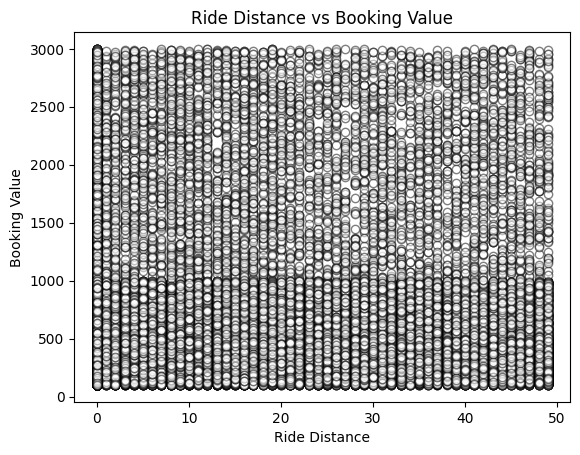

In [16]:
#Ride Distance vs Booking Value (Scatter Plot)
plt.figure()
plt.scatter(df['Ride_Distance'], df['Booking_Value'], alpha=0.5, color='white', edgecolor='black')
plt.title('Ride Distance vs Booking Value')
plt.xlabel('Ride Distance')
plt.ylabel('Booking Value')
plt.show()

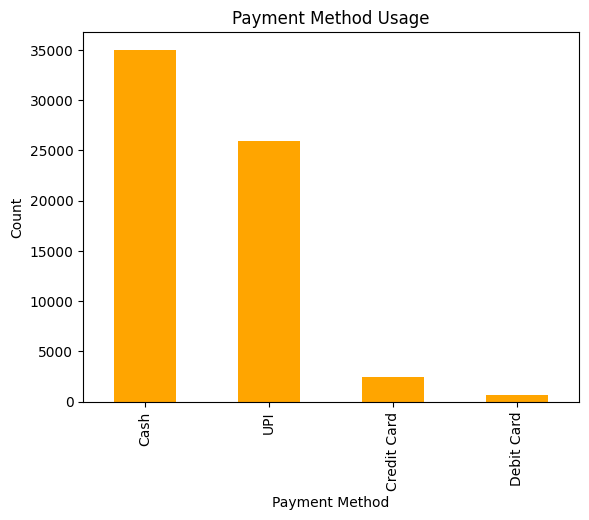

In [17]:
#Payment Method Usage
plt.figure()
df['Payment_Method'].value_counts().plot(kind='bar', color='orange')
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

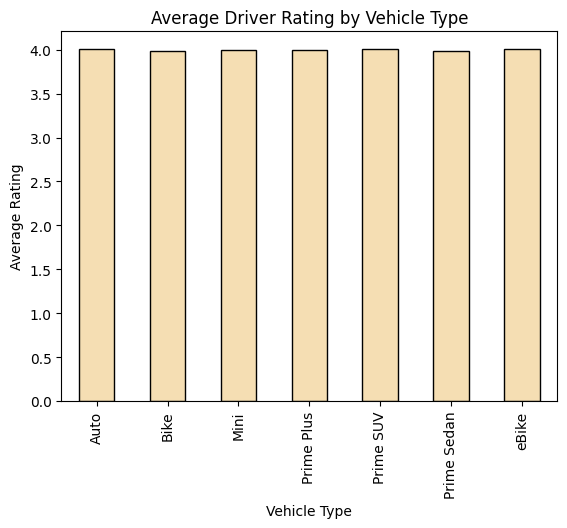

In [18]:
# Average Driver Rating by Vehicle Type
avg_driver_rating = df.groupby('Vehicle_Type')['Driver_Ratings'].mean()

plt.figure()
avg_driver_rating.plot(kind='bar', color='wheat', edgecolor='black')
plt.title('Average Driver Rating by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Rating')
plt.show()

In [19]:
# inshights and conclusions
print("\nAverage Booking Value:", df['Booking_Value'].mean())
print("Average Ride Distance:", df['Ride_Distance'].mean())
print("\nTop Pickup Locations:")
print(df['Pickup_Location'].value_counts().head())

print("\nTop Drop Locations:")
print(df['Drop_Location'].value_counts().head())


Average Booking Value: 548.7518830563752
Average Ride Distance: 14.189926619040223

Top Pickup Locations:
Pickup_Location
Banashankari     2201
Yeshwanthpur     2139
RT Nagar         2135
Indiranagar      2133
Sahakar Nagar    2126
Name: count, dtype: int64

Top Drop Locations:
Drop_Location
Peenya         2159
Mysore Road    2148
MG Road        2128
Hennur         2120
HSR Layout     2117
Name: count, dtype: int64


In [21]:
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,#NAME?,NaN
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,No,NaN,158,Cash,13,4.1,4.0,#NAME?,NaN
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,No,NaN,386,UPI,40,4.2,4.8,#NAME?,NaN
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,NaN,NaN,384,NaN,0,NaN,NaN,#NAME?,NaN
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,No,NaN,822,Credit Card,45,4.0,3.0,#NAME?,NaN


In [20]:
#inshights
#Missing values are logical, not data errors (due to ride cancellations).

#conclusions
#The dataset represents real-world ride booking behavior with logical missing values due to ride cancellations.
#After cleaning and preprocessing, the data is suitable for visualization and analysis. 
#EDA reveals that most rides are successful, shorter distance trips are more frequent, and booking value increases with distance and vehicle type.
#Ratings indicate generally positive customer experience.